# DAIC-WOZ Depression Detection with Mamba/LSTM

This notebook implements a deep learning pipeline for depression detection using the DAIC-WOZ dataset. It covers data loading, preprocessing with `StandardScaler`, and custom `Dataset` and `DataLoader` for handling windowed participant data. The core of the model is a `ParticipantDepressionNet` architecture, initially explored with BiLSTM and attention mechanisms, and later modified to integrate the Mamba State Space Model for improved sequential data processing across windows. The notebook includes functions for training, validation, and evaluation, along with an early stopping mechanism. Finally, it visualizes training metrics and performs a cosine similarity analysis on sample feature vectors.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [ ]:
BASE_DIR      = Path("/content/drive/MyDrive")
PROCESSED_DIR = BASE_DIR / "DAIC_WOZ_VIDEO_BRANCH" / "data" / "processed"
WINDOWS_DIR   = PROCESSED_DIR / "windows_processed"
NEW_PROC_DIR  = PROCESSED_DIR / "new_processed"

In [ ]:
FPS         = 30
WINDOW_SIZE = 300    # 10 sec @ 30fps
STRIDE      = 150    # 5 sec overlap
BATCH_SIZE  = 4      # participants per batch
NUM_EPOCHS  = 80
PATIENCE    = 20
LR          = 1e-4
ALPHA       = 0.02  # regression loss weight
DROP_FEATURES = ["frame", "timestamp", "confidence", "success"]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PROCESSED_DIR exists: {PROCESSED_DIR.exists()}")

Device: cuda
PROCESSED_DIR exists: True


In [ ]:
# @title
session_ids = [300,
 301,
 302,
 303,
 304,
 305,
 306,
 307,
 308,
 309,
 310,
 311,
 312,
 313,
 314,
 315,
 316,
 317,
 318,
 319,
 320,
 321,
 322,
 323,
 324,
 325,
 326,
 327,
 328,
 329,
 330,
 331,
 332,
 333,
 334,
 335,
 336,
 337,
 338,
 339,
 340,
 341,
 343,
 344,
 345,
 346,
 347,
 348,
 349,
 350,
 351,
 352,
 353,
 354,
 355,
 356,
 357,
 358,
 359,
 360,
 361,
 362,
 363,
 364,
 365,
 366,
 367,
 368,
 369,
 370,
 371,
 372,
 373,
 374,
 375,
 376,
 377,
 378,
 379,
 380,
 381,
 382,
 383,
 384,
 385,
 386,
 387,
 388,
 389,
 390,
 391,
 392,
 393,
 395,
 396,
 397,
 399,
 400,
 401,
 402,
 403,
 404,
 405,
 406,
 407,
 408,
 409,
 410,
 411,
 412,
 413,
 414,
 415,
 416,
 417,
 418,
 419,
 420,
 421,
 422,
 423,
 424,
 425,
 426,
 427,
 428,
 429,
 430,
 431,
 432,
 433,
 434,
 435,
 436,
 437,
 438,
 439,
 440,
 441,
 442,
 443,
 444,
 445,
 446,
 447,
 448,
 449,
 450,
 451,
 452,
 453,
 454,
 455,
 456,
 457,
 458,
 459,
 461,
 462,
 463,
 464,
 465,
 466,
 467,
 468,
 469,
 470,
 471,
 472,
 473,
 474,
 475,
 476,
 477,
 478,
 479,
 480,
 481,
 482,
 483,
 484,
 485,
 486,
 487,
 488,
 489,
 490,
 491,
 492,
 601,
 603,
 608,
 612,
 617,
 627,
 628,
 632,
 633,
 641,
 653,
 654,
 657,
 660,
 662,
 667,
 670,
 673,
 677,
 680,
 684,
 687,
 692,
 695,
 697,
 698,
 702,
 703,
 707,
 713]

In [ ]:
metadata_df = pd.read_csv(WINDOWS_DIR / "metadata.csv")

train_df = metadata_df[metadata_df["split"] == "train"].reset_index(drop=True)
val_df   = metadata_df[metadata_df["split"] == "val"].reset_index(drop=True)
test_df  = metadata_df[metadata_df["split"] == "test"].reset_index(drop=True)

print(f"Train: {len(train_df)} participants | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nTrain labels:\n", train_df["binary_label"].value_counts())
print("\nVal labels:\n",   val_df["binary_label"].value_counts())
print("\nTest labels:\n",  test_df["binary_label"].value_counts())

Train: 131 participants | Val: 44 | Test: 44

Train labels:
 binary_label
0    92
1    39
Name: count, dtype: int64

Val labels:
 binary_label
0    31
1    13
Name: count, dtype: int64

Test labels:
 binary_label
0    31
1    13
Name: count, dtype: int64


In [ ]:
def phq_to_class(score):
    if score <= 4:
        return 0
    elif score <= 9:
        return 1
    elif score <= 14:
        return 2
    elif score <= 19:
        return 3
    else:
        return 4

metadata_df["severity_class"] = metadata_df["phq_score"].apply(phq_to_class)

In [ ]:
all_train_frames = []

for _, row in train_df.iterrows():

    windows = np.load(
        row["window_file"]
    )

    frames = windows.reshape(
        -1,
        windows.shape[-1]
    )

    all_train_frames.append(frames)

In [ ]:
print("Train frames shape:", len(all_train_frames))

Train frames shape: 131


In [ ]:
all_train_frames = np.concatenate(
    all_train_frames,
    axis=0
)

print(all_train_frames.shape)

(7309500, 49)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# scaler.fit(all_train_frames)

In [ ]:
for _, row in train_df.iterrows():
    windows = np.load(row["window_file"])
    frames  = windows.reshape(-1, windows.shape[-1])
    scaler.partial_fit(frames)
import gc
del frames, all_train_frames
gc.collect()

855

In [ ]:
import joblib

joblib.dump(
    scaler,
    PROCESSED_DIR/ "scaler.pkl"
)

['/content/drive/MyDrive/DAIC_WOZ_VIDEO_BRANCH/data/processed/scaler.pkl']

In [ ]:
import joblib
scaler = joblib.load(
    PROCESSED_DIR/ "scaler.pkl"
)

In [ ]:
# sample = all_train_frames[:1000]

# normalized = scaler.transform(sample)

# print(normalized.mean(axis=0)[:5])
# print(normalized.std(axis=0)[:5])

In [ ]:
# # check
# sample = scaler.transform(all_train_frames[:1000])
# print("Mean (should be ~0):", sample.mean(axis=0)[:5].round(4))
# print("Std  (should be ~1):", sample.std(axis=0)[:5].round(4))

In [ ]:
BATCH_SIZE

4

In [ ]:
class ParticipantDataset(Dataset):
    """
    One sample = one participant (all their windows).
    Scaler is applied here — val/test are transformed with train scaler,
    which is the correct way to avoid leakage.
    """
    def __init__(self, metadata_df, scaler):
        self.metadata = metadata_df.reset_index(drop=True)
        self.scaler   = scaler

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row      = self.metadata.iloc[idx]
        raw      = np.load(row["window_file"])  # (W, 300, 49)
        W, T, F  = raw.shape
        scaled   = self.scaler.transform(
            raw.reshape(-1, F), copy=False
        ).reshape(W, T, F).astype(np.float32, copy=False)
        return {
            "windows":        torch.from_numpy(scaled),
            "binary_label":   torch.tensor(row["binary_label"], dtype=torch.long),
            "phq_score":      torch.tensor(row["phq_score"],    dtype=torch.float32),
            "participant_id": row["participant_id"]
        }


def participant_collate(batch):
    """
    Pads windows along the W (num_windows) dimension so variable-length
    participants can be batched. num_windows tracks the real lengths
    so padding is masked out in the model.
    """
    windows     = [x["windows"] for x in batch]                # list of (W_i, 300, 49)
    num_windows = torch.tensor([w.shape[0] for w in windows])  # (B,)
    padded      = pad_sequence(windows, batch_first=True)       # (B, W_max, 300, 49)
    return {
        "windows":        padded,
        "num_windows":    num_windows,
        "binary_label":   torch.stack([x["binary_label"] for x in batch]),
        "phq_score":      torch.stack([x["phq_score"]    for x in batch]),
        "participant_id": [x["participant_id"]            for x in batch]
    }


scaler = joblib.load(PROCESSED_DIR / "scaler.pkl")

train_dataset = ParticipantDataset(train_df, scaler)
val_dataset   = ParticipantDataset(val_df,   scaler)
test_dataset  = ParticipantDataset(test_df,  scaler)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=participant_collate,
    # num_workers=0,        # don't set too high — each worker copies RAM
    # pin_memory=False

)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=participant_collate
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=participant_collate
)

batch = next(iter(train_loader))
print("windows shape: ", batch["windows"].shape)     # (B, W_max, 300, 49)
print("num_windows:   ", batch["num_windows"])
print("binary_label:  ", batch["binary_label"])

windows shape:  torch.Size([4, 201, 300, 49])
num_windows:    tensor([201, 160, 118, 192])
binary_label:   tensor([0, 1, 0, 0])


In [ ]:
# class ParticipantDepressionNet(nn.Module):
#     """
#     Two-level architecture:
#       Level 1 — BiLSTM + attention pools each 10-sec window -> window embedding
#       Level 2 — Masked mean across VALID windows only -> participant embedding

#     Key fixes vs original:
#       - num_windows mask excludes zero-padded windows from the mean
#       - LayerNorm after shared linear for stable training
#       - 2-layer BiLSTM with dropout
#     """
#     def __init__(
#         self,
#         input_size=49,
#         hidden_size=64,
#         num_layers=2,
#         dropout=0.3
#     ):
#         super().__init__()

#         # --- Level 1: per-window encoder ---
#         self.window_encoder = nn.LSTM(
#             input_size=input_size,
#             hidden_size=hidden_size,
#             num_layers=num_layers,
#             batch_first=True,
#             dropout=dropout,
#             bidirectional=True
#         )
#         lstm_out_dim = hidden_size * 2  # 128
#         self.window_attention = nn.Linear(lstm_out_dim, 1)

#         # --- Level 2: participant classifier/regressor ---
#         self.shared = nn.Sequential(
#             nn.Linear(lstm_out_dim, 64),
#             nn.LayerNorm(64),
#             nn.ReLU(),
#             nn.Dropout(dropout)
#         )
#         self.classifier = nn.Linear(64, 2)
#         self.regressor  = nn.Linear(64, 1)




#     def encode_window(self, windows_flat):
#         """windows_flat: (B*W, T, F) -> (B*W, lstm_out_dim)"""
#         lstm_out, _ = self.window_encoder(windows_flat)          # (B*W, T, 128)
#         scores      = self.window_attention(lstm_out).squeeze(-1) # (B*W, T)
#         weights     = torch.softmax(scores, dim=1)                # (B*W, T)
#         embeddings  = (lstm_out * weights.unsqueeze(-1)).sum(dim=1) # (B*W, 128)
#         return embeddings

#     def forward(self, windows, num_windows):
#         """
#         windows:     (B, W_max, T, F)
#         num_windows: (B,)  — real window count per participant
#         """
#         B, W, T, F   = windows.shape
#         windows_flat = windows.reshape(B * W, T, F)
#         embeddings   = self.encode_window(windows_flat)  # (B*W, 128)
#         embeddings   = embeddings.reshape(B, W, -1)      # (B, W, 128)

#         # Mask out padding before averaging
#         mask = torch.zeros(B, W, 1, device=windows.device)
#         for i, n in enumerate(num_windows):
#             mask[i, :n] = 1.0

#         participant_emb = (
#             (embeddings * mask).sum(dim=1)
#             / mask.sum(dim=1).clamp(min=1)
#         )  # (B, 128)

#          # ---------------------------------------
#         packed_out, (h_n, _) = self.participant_encoder(packed)
#         out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
#         # out: (B, W_max, 64) — hidden state at every window step

#         # attention over the trajectory
#         scores  = self.traj_attention(out).squeeze(-1)          # (B, W_max)
#         mask    = (torch.arange(W)[None,:] >= num_windows[:,None]).to(windows.device)
#         scores  = scores.masked_fill(mask, -1e9)
#         weights = torch.softmax(scores, dim=1)                  # (B, W_max)
#         participant_emb = (out * weights.unsqueeze(-1)).sum(1)  # (B, 64)
#         # ---------------------------------------

#         shared = self.shared(participant_emb)
#         return {
#             "class_logits": self.classifier(shared),  # (B, 2)
#             "phq_score":    self.regressor(shared)    # (B, 1)
#         }


# # Shape test
# model = ParticipantDepressionNet().to(device)
# out   = model(
#     batch["windows"].to(device),
#     batch["num_windows"]
# )
# print("class_logits:", out["class_logits"].shape)
# print("phq_score:   ", out["phq_score"].shape)

class_logits: torch.Size([4, 2])
phq_score:    torch.Size([4, 1])


In [ ]:
!pip install mamba-ssm

  Using cached mamba_ssm-2.3.2.post1.tar.gz (216 kB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
# @title
!pip install torch==2.4.0 --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.7/857.7 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 57.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 36.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 67.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 779.6 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 14.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.9/142.9 MB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1

In [ ]:
!pip install causal-conv1d>=1.4.0
!pip install mamba-ssm --no-build-isolation

  error: subprocess-exited-with-error
  
  × Building wheel for causal-conv1d (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for causal-conv1d
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (causal-conv1d)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
  Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.7/327.7 kB 28.6 MB/s eta 0:00:00
Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (180 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from mamba_ssm import Mamba

SyntaxError: invalid syntax (359653465.py, line 1)

In [ ]:
class ParticipantDepressionNet(nn.Module):
    def __init__(
        self,
        input_size   = 49,
        win_hidden   = 64,    # level 1 — within window
        part_hidden  = 64,    # level 2 — across windows
        num_layers   = 2,
        dropout      = 0.3
    ):
        super().__init__()

        # ── Level 1: per-window BiLSTM (same as before) ──────────────────
        self.window_encoder = nn.LSTM(
            input_size   = input_size,
            hidden_size  = win_hidden,
            num_layers   = num_layers,
            batch_first  = True,
            dropout      = dropout,
            bidirectional= True
        )
        win_out_dim = win_hidden * 2   # 128

        self.window_attention = nn.Linear(win_out_dim, 1)

        # ── Level 2: across-window LSTM (NEW) ────────────────────────────
        # takes the sequence of window embeddings as input
        # unidirectional — past windows can inform future, not vice versa
        # self.participant_encoder = nn.LSTM(
        #     input_size  = win_out_dim,   # 128
        #     hidden_size = part_hidden,   # 64
        #     num_layers  = 1,
        #     batch_first = True,
        #     dropout     = 0.0,           # single layer, no dropout needed
        #     bidirectional = False        # causal — past → future only
        # )



        self.participant_encoder = Mamba(
            d_model=win_out_dim,  # 128
            d_state=64,           # state expansion
            d_conv=4,             # local convolution width
            expand=2              # block expansion
        )
        self.participant_attention = nn.Linear(
            win_out_dim,
            1
        )

        # ── Level 3: classifier/regressor (same as before) ───────────────
        self.shared = nn.Sequential(
            nn.Linear(part_hidden, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.classifier = nn.Linear(64, 2)
        self.regressor  = nn.Linear(64, 1)


    def encode_window(self, windows_flat):
        """(B*W, T, F) → (B*W, 128)  — unchanged from before"""
        lstm_out, _ = self.window_encoder(windows_flat)
        scores      = self.window_attention(lstm_out).squeeze(-1)
        weights     = torch.softmax(scores, dim=1)
        return (lstm_out * weights.unsqueeze(-1)).sum(dim=1)


    def forward(self, windows, num_windows):
        B, W, T, F = windows.shape

        # ── Level 1: encode each window independently ─────────────────
        windows_flat = windows.reshape(B * W, T, F)
        embeddings   = self.encode_window(windows_flat)   # (B*W, 128)
        window_embeddings   = embeddings.reshape(B, W, 128)      # (B, W, 128)


        participant_out = self.participant_encoder(
            window_embeddings
        )

        B, W, D = participant_out.shape

        mask = (
            torch.arange(W, device=num_windows.device)
            .expand(B, W)
            < num_windows.unsqueeze(1)
        )

        scores = self.participant_attention(
            participant_out
        ).squeeze(-1)

        scores = scores.masked_fill(
            ~mask,
            float("-inf")
        )

        weights = torch.softmax(
            scores,
            dim=1
        )

        participant_repr = torch.sum(
            participant_out * weights.unsqueeze(-1),
            dim=1
        )

        # # ── Level 2: run window embeddings through participant LSTM ───
        # # pack so padded windows don't affect the hidden state
        # packed = nn.utils.rnn.pack_padded_sequence(
        #     embeddings,
        #     num_windows.cpu(),
        #     batch_first  = True,
        #     enforce_sorted = False          # don't need to pre-sort
        # )
        # packed_out, (h_n, _) = self.participant_encoder(packed)

        # # h_n is (1, B, 64) — the hidden state AFTER the last REAL window
        # # this is your participant summary with full sequential context
        # participant_emb = h_n.squeeze(0)   # (B, 64)

        # # ── Level 3: classify/regress ──────────────────────────────────
        # shared = self.shared(participant_emb)
        return {
            "class_logits": self.classifier(participant_repr),   # (B, 2)
            "phq_score":    self.regressor(participant_repr)     # (B, 1)
        }

In [ ]:
# Class weights computed from train participants only
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["binary_label"].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights)

cls_criterion = nn.CrossEntropyLoss(weight=class_weights)
reg_criterion = nn.MSELoss()

model     = ParticipantDepressionNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

Class weights: tensor([0.7120, 1.6795], device='cuda:0')


NameError: name 'Mamba' is not defined

In [ ]:
class_weights = torch.tensor([0.7,2.5], dtype=torch.float32).to(device)

In [ ]:
def train_one_epoch(model, loader, optimizer, device, alpha=ALPHA):
    model.train()
    total_loss = total_cls = total_reg = 0

    for batch in loader:
        windows       = batch["windows"].to(device)
        num_windows   = batch["num_windows"]
        binary_labels = batch["binary_label"].to(device)
        phq_scores    = batch["phq_score"].to(device)

        optimizer.zero_grad()
        outputs  = model(windows, num_windows)

        cls_loss = cls_criterion(outputs["class_logits"], binary_labels)
        reg_loss = reg_criterion(outputs["phq_score"].squeeze(1), phq_scores)
        loss     = cls_loss + alpha * reg_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_cls  += cls_loss.item()
        total_reg  += reg_loss.item()

    n = len(loader)
    return total_loss / n, total_cls / n, total_reg / n


def validate(model, loader, device, alpha=ALPHA):
    model.eval()
    total_loss   = 0
    all_preds    = []; all_labels   = []
    all_phq_pred = []; all_phq_true = []

    with torch.no_grad():
        for batch in loader:
            windows       = batch["windows"].to(device)
            num_windows   = batch["num_windows"]
            binary_labels = batch["binary_label"].to(device)
            phq_scores    = batch["phq_score"].to(device)

            outputs  = model(windows, num_windows)
            cls_loss = cls_criterion(outputs["class_logits"], binary_labels)
            reg_loss = reg_criterion(outputs["phq_score"].squeeze(1), phq_scores)
            total_loss += (cls_loss + alpha * reg_loss).item()

            preds = torch.argmax(outputs["class_logits"], dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(binary_labels.cpu().numpy())
            all_phq_pred.extend(outputs["phq_score"].squeeze(1).cpu().numpy())
            all_phq_true.extend(phq_scores.cpu().numpy())

    f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    acc  = accuracy_score(all_labels, all_preds)
    rmse = np.sqrt(mean_squared_error(all_phq_true, all_phq_pred))
    return total_loss / len(loader), acc, f1, rmse

In [ ]:
best_f1          = 0
patience_counter = 0
history          = []
batch_size       = BATCH_SIZE

print("=" * 65)
print(f"Device: {device}  |  Train: {len(train_dataset)} participants  |  Val: {len(val_dataset)}")
print(f"Batch: {BATCH_SIZE}  |  LR: {LR}  |  Epochs: {NUM_EPOCHS}  |  Patience: {PATIENCE}")
print("=" * 65)

for epoch in range(NUM_EPOCHS):

    tr_loss, tr_cls, tr_reg = train_one_epoch(
        model, train_loader, optimizer, device
    )
    val_loss, val_acc, val_f1, val_rmse = validate(
        model, val_loader, device
    )
    scheduler.step()

    history.append({
        "epoch":      epoch + 1,
        "train_loss": tr_loss,
        "val_loss":   val_loss,
        "val_acc":    val_acc,
        "val_f1":     val_f1,
        "val_rmse":   val_rmse
    })

    print(
        f"Epoch {epoch+1:03d} | "
        f"TrLoss={tr_loss:.4f} (cls={tr_cls:.4f} reg={tr_reg:.4f}) | "
        f"ValLoss={val_loss:.4f} | "
        f"Acc={val_acc:.4f} | "
        f"F1(macro)={val_f1:.4f} | "
        f"RMSE={val_rmse:.4f}"
    )

    if val_f1 > best_f1:
        best_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), "best_participant_model.pt")
        print(f"  New best F1={best_f1:.4f} — model saved")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

print(f"\nBest val macro-F1: {best_f1:.4f}")

Device: cuda  |  Train: 131 participants  |  Val: 44
Batch: 4  |  LR: 0.0001  |  Epochs: 80  |  Patience: 20
Epoch 001 | TrLoss=2.5490 (cls=0.7994 reg=87.4773) | ValLoss=1.9656 | Acc=0.2955 | F1(macro)=0.2281 | RMSE=7.7110
  New best F1=0.2281 — model saved
Epoch 002 | TrLoss=2.3013 (cls=0.7237 reg=78.8779) | ValLoss=1.7840 | Acc=0.3182 | F1(macro)=0.3168 | RMSE=7.3265
  New best F1=0.3168 — model saved
Epoch 003 | TrLoss=2.1413 (cls=0.6827 reg=72.9289) | ValLoss=1.6615 | Acc=0.6364 | F1(macro)=0.5152 | RMSE=6.9549
  New best F1=0.5152 — model saved
Epoch 004 | TrLoss=2.1072 (cls=0.7221 reg=69.2564) | ValLoss=1.5849 | Acc=0.6591 | F1(macro)=0.4532 | RMSE=6.6841
  No improvement (1/20)
Epoch 005 | TrLoss=1.9508 (cls=0.6798 reg=63.5525) | ValLoss=1.5361 | Acc=0.6818 | F1(macro)=0.5111 | RMSE=6.4856
  No improvement (2/20)
Epoch 006 | TrLoss=1.9097 (cls=0.6843 reg=61.2733) | ValLoss=1.5042 | Acc=0.6818 | F1(macro)=0.5111 | RMSE=6.3597
  No improvement (3/20)
Epoch 007 | TrLoss=1.8750 (cls

In [ ]:
SAVE_DIR = BASE_DIR / "DAIC_WOZ_VIDEO_BRANCH" / "results" / "models"

In [ ]:
# full inference bundle — one file has everything
BUNDLE_PATH = SAVE_DIR / "_4.0_2layer_lstm_video.pt"

torch.save({
    # model
    "model_state_dict":  model.state_dict(),
    "model_config": {
        "input_size":  49,
        "hidden_size": 64,
        "num_layers":  2,
        "dropout":     0.3
    },
    # scaler — embed directly so inference needs no extra files
    "scaler_mean":   torch.tensor(scaler.mean_,   dtype=torch.float32),
    "scaler_scale":  torch.tensor(scaler.scale_,  dtype=torch.float32),
    # training outcome
    "best_f1":       best_f1,
    "history":       history,
    "label_map":     {0: "non-depressed", 1: "depressed"}
}, BUNDLE_PATH)

print(f"\nInference bundle saved → {BUNDLE_PATH}")


Inference bundle saved → /content/drive/MyDrive/DAIC_WOZ_VIDEO_BRANCH/results/models/_4.0_2layer_lstm_video.pt


In [ ]:
bundle = torch.load(BUNDLE_PATH, map_location=device, weights_only=False)

# reconstruct model
cfg   = bundle["model_config"]

# Adapt the config for the current model's __init__ signature
adapted_cfg = {
    "input_size": cfg["input_size"],
    "win_hidden": cfg["hidden_size"],  # Map old hidden_size to new win_hidden
    "part_hidden": cfg["hidden_size"], # Map old hidden_size to new part_hidden
    "num_layers": cfg["num_layers"],
    "dropout": cfg["dropout"]
}
model = ParticipantDepressionNet(**adapted_cfg).to(device)
model.load_state_dict(bundle["model_state_dict"])
model.eval()

# reconstruct scaler
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler         = StandardScaler()
scaler.mean_   = bundle["scaler_mean"].cpu().numpy()
scaler.scale_  = bundle["scaler_scale"].cpu().numpy()
scaler.var_    = scaler.scale_ ** 2
scaler.n_features_in_ = 49

print(f"Loaded model — best val F1: {bundle['best_f1']:.4f}")

Loaded model — best val F1: 0.5152


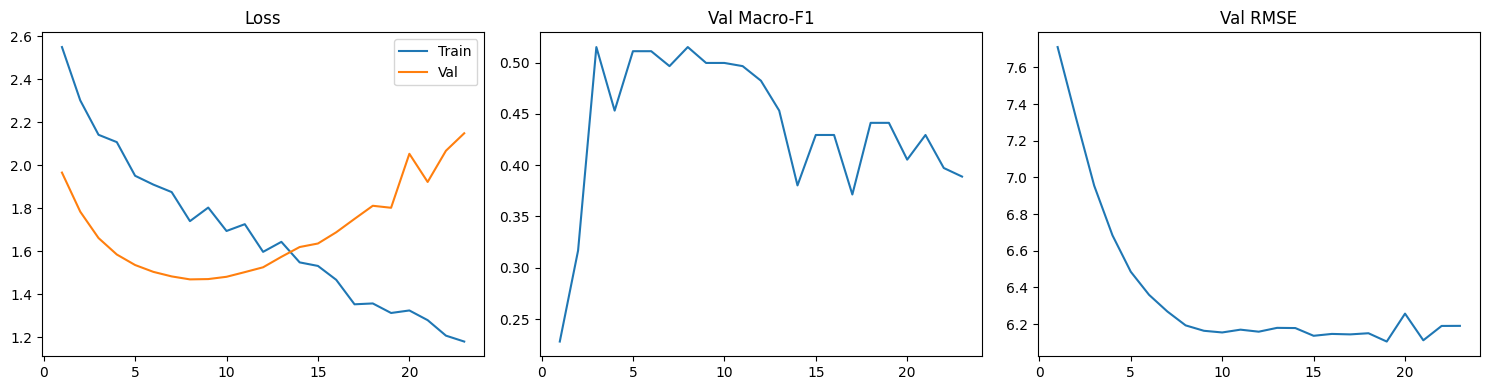

In [ ]:
hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(hist["epoch"], hist["train_loss"], label="Train")
axes[0].plot(hist["epoch"], hist["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(hist["epoch"], hist["val_f1"])
axes[1].set_title("Val Macro-F1")

axes[2].plot(hist["epoch"], hist["val_rmse"])
axes[2].set_title("Val RMSE")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()

In [ ]:
def evaluate(model, loader, device):
    model.eval()
    all_cls_preds  = []; all_cls_labels = []
    all_phq_preds  = []; all_phq_labels = []

    with torch.no_grad():
        for batch in loader:
            windows       = batch["windows"].to(device)
            num_windows   = batch["num_windows"]
            binary_labels = batch["binary_label"].to(device)
            phq_scores    = batch["phq_score"].to(device)

            outputs   = model(windows, num_windows)
            cls_preds = torch.argmax(outputs["class_logits"], dim=1)

            all_cls_preds.extend(cls_preds.cpu().numpy())
            all_cls_labels.extend(binary_labels.cpu().numpy())
            all_phq_preds.extend(outputs["phq_score"].squeeze(1).cpu().numpy())
            all_phq_labels.extend(phq_scores.cpu().numpy())

    return {
        "accuracy":         accuracy_score(all_cls_labels, all_cls_preds),
        "precision":        precision_score(all_cls_labels, all_cls_preds, average="macro", zero_division=0),
        "recall":           recall_score(all_cls_labels, all_cls_preds,    average="macro", zero_division=0),
        "f1":               f1_score(all_cls_labels, all_cls_preds,        average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(all_cls_labels, all_cls_preds),
        "mae":              mean_absolute_error(all_phq_labels, all_phq_preds),
        "rmse":             np.sqrt(mean_squared_error(all_phq_labels, all_phq_preds)),
        "r2":               r2_score(all_phq_labels, all_phq_preds),
        "all_phq_preds":    all_phq_preds,
        "all_phq_labels":   all_phq_labels
    }


model.load_state_dict(torch.load("best_participant_model.pt", map_location=device))
model.to(device)

test_metrics = evaluate(model, test_loader, device)

print("\n" + "=" * 50)
print("TEST RESULTS  (participant-level)")
print("=" * 50)
for k, v in test_metrics.items():
    if k != "confusion_matrix" and k != "all_phq_preds" and k != "all_phq_labels":
        print(f"{k:<15}: {v:.4f}")
print("\nConfusion Matrix:")
print(test_metrics["confusion_matrix"])


TEST RESULTS  (participant-level)
accuracy       : 0.7500
precision      : 0.7500
recall         : 0.5993
f1             : 0.5990
mae            : 6.1092
rmse           : 8.3172
r2             : -0.8747

Confusion Matrix:
[[30  1]
 [10  3]]


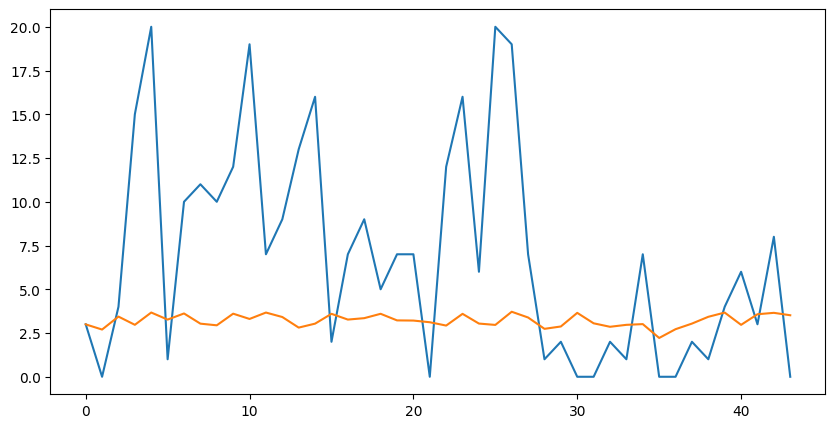

In [ ]:
# plot of true phq_score and predicted phq_score
plt.figure(figsize=(10, 5))
# plt.scatter(test_metrics["all_phq_labels"], test_metrics["all_phq_preds"])
# plt.plot(test_metrics["all_phq_labels"], test_metrics["all_phq_preds"])
plt.plot(test_metrics["all_phq_labels"])
plt.plot(test_metrics["all_phq_preds"])

In [ ]:
import numpy as np
# non-depressed female:
vec_a = np.array([0.3295780757,0.6087525217,0,4.27,0.01,0,0.43,0.121416108,0.3032664749,0,3.54,0,0,0.06,1.524663841,0.6273113298,0,3.98,1.57,1.09,1.92,0.09458891956,0.2738239993,0,3.02,0,0,0.01,0.6710365733,0.379844516,0,2.73,0.63,0.41,0.88,1.358743592,0.6317870242,0,4.03,1.34,0.92,1.74,0.07494873817,0.1607377367,0,2.36,0,0,0.08,1.17223334,0.5917321601,0,2.82,1.29,0.67,1.65,0.09804712145,0.2475076102,0,2.23,0,0,0.06,0.859919164,0.6040926593,0,4.11,0.79,0.43,1.16,0.2664101932,0.3996889227,0,5,0.02,0,0.47,0.6406664038,0.5317233784,0,3.68,0.58,0.15,1.01,0.1336450118,0.2464438271,0,2.1,0,0,0.15,0.2002459582,0.3772158294,0,4.8,0,0,0.23,0.7904056585,0.8232402895,0,4.54,0.46,0.02,1.5,0.5979500197,0.6452121286,0,3.92,0.39,0.02,0.97,0.5642394519,0.84856779,0,3.87,0,0,1.06,0.3178233438,0.4656303963,0,1,0,0,1,0.277011041,0.4475219818,0,1,0,0,1,0.7620268139,0.4258426339,0,1,1,1,1,0.01700512618,0.1292901847,0,1,0,0,0,0.08088525237,0.272658813,0,1,0,0,0,0.4530757098,0.4977932412,0,1,0,0,1,0.04514984227,0.2076326901,0,1,0,0,0,0.6863170347,0.4639891837,0,1,1,0,1,0.01483635647,0.1208976385,0,1,0,0,0,0.5526419558,0.4972211022,0,1,1,0,1,0.2321076498,0.4221773191,0,1,0,0,0,0.3299980284,0.470212005,0,1,0,0,1,0.05062105678,0.2192226389,0,1,0,0,0,0.002563091483,0.05056206132,0,1,0,0,0,0.3154574132,0.4646977875,0,1,0,0,1,0.2999309937,0.4582274465,0,1,0,0,1,0.005126182965,0.07141362064,0,1,0,0,0,0.4179317823,0.4932188233,0,1,0,0,1,0.1892002246,0.06044879402,-0.160302,0.77363,0.180276,0.156529,0.21079725,0.2002275252,0.08429256838,-0.173018,0.612622,0.205967,0.149535,0.250981,-0.9552906931,0.02779591104,-0.999959,-0.581712,-0.9618515,-0.97221125,-0.94814475,0.04083183636,0.06982322385,-0.370027,0.629683,0.055547,-0.00085475,0.087026,0.2319578449,0.08697946566,-0.177282,0.680507,0.239188,0.17364175,0.2826995,-0.9651828363,0.02257661889,-0.999975,-0.697641,-0.96835,-0.9814885,-0.956305,0.1190406644,0.04892618181,-0.234,0.742,0.123,0.097,0.144,0.221526321,0.08575563757,-0.176,0.7,0.227,0.17,0.267,-126.7264836,15.78569496,-194.3,39.6,-129.6,-136.4,-116.9,37.9561317,18.98643391,-37.5,229.3,38.5,26,50.7,547.0298304,19.51059188,386.2,786.6,546.3,535.7,557.3,0.0005262716877,0.08126774497,-0.363,0.862,0.017,-0.061,0.056,-0.04008551853,0.08641045019,-0.744,0.379,-0.014,-0.103,0.019,-0.007914432177,0.1420610168,-0.318,0.875,-0.074,-0.116,0.14,0.7690836948,0.5424465329,0.2440358833,1.791074034,0.6808515807,0.5587493041,0.1563830289,0.4179317823,0.2601426142,0.07292786662,0.01347180808,0.01886304769,0.01018966472,0.01404307682,2.14475238,3.1379218])
# depressed female:
vec_b= np.array([0.4091771441,0.7191595046,0,5,0.01,0,0.52,0.1930164078,0.4569338225,0,4.47,0,0,0.08,0.9756194702,0.7673287969,0,5,0.88,0.34,1.47,0.1479382036,0.4017266916,0,3.66,0,0,0,0.3037625661,0.4469817999,0,3.64,0.1,0,0.46,0.720246802,0.689430662,0,5,0.57,0.11,1.12,0.1323362643,0.2799831554,0,2.82,0,0,0.11,1.116378503,0.6723000348,0,3.93,1.1,0.62,1.58,0.388615334,0.4908066011,0,3.73,0.23,0.01,0.56,0.9669131947,0.8186051793,0,4.58,0.87,0.2,1.55,0.2627912455,0.4162987218,0,5,0.02,0,0.42,0.4424192621,0.4036200155,0,3.86,0.37,0.11,0.67,0.1397175884,0.2717078917,0,5,0,0,0.17,0.2543980606,0.4988365363,0,5,0,0,0.31,0.811435889,0.8224731914,0,5,0.6,0.01,1.37,0.5823740652,0.6217916879,0,4.79,0.42,0.03,0.94,0.3832722492,0.6258599955,0,3.79,0,0,0.59,0.2815350481,0.4497477791,0,1,0,0,1,0.3287862602,0.4697721312,0,1,0,0,1,0.8169392171,0.3867163465,0,1,1,1,1,0.05472923001,0.2274509648,0,1,0,0,0,0.05864628701,0.2349614863,0,1,0,0,0,0.7480209275,0.4341493056,0,1,1,0,1,0.2267784261,0.4187481003,0,1,0,0,0,0.6079382036,0.4882103483,0,1,1,0,1,0.1314268496,0.3378665903,0,1,0,0,0,0.6722546361,0.4693914575,0,1,1,0,1,0.1004464897,0.3005943985,0,1,0,0,0,0.3511655299,0.4773345792,0,1,0,0,1,0.2313254992,0.4216799884,0,1,0,0,0,0.2666885803,0.4422282006,0,1,0,0,1,0.363272797,0.480942483,0,1,0,0,1,0.2216835128,0.415379264,0,1,0,0,0,0.0113402909,0.105885262,0,1,0,0,0,0.3265127236,0.4689372718,0,1,0,0,1,-0.08966123286,0.1272782686,-0.515989,0.579454,-0.067605,-0.143739,-0.021583,0.2411693955,0.08937674275,-0.284337,0.668,0.234959,0.1784525,0.3032465,-0.9532692711,0.02979802935,-0.999894,-0.739137,-0.957873,-0.9788055,-0.9314105,-0.2984725275,0.1301626744,-0.687458,0.443549,-0.279097,-0.373946,-0.2001225,0.2285430655,0.09927706153,-0.363694,0.720914,0.229697,0.1622855,0.291595,-0.9100507952,0.0607577818,-0.999942,-0.626666,-0.925393,-0.9605985,-0.8739965,-0.20591692,0.1337946996,-0.665,0.517,-0.172,-0.272,-0.12,0.2475965157,0.09296565346,-0.338,0.687,0.248,0.182,0.31,72.66448352,31.34125763,19.5,1615.6,70.4,59.4,81.4,61.45231599,31.27090513,-75.9,963.8,59.6,45.9,75,542.5151478,36.19103576,355.3,2763.2,542.6,530.9,553.7,0.1551088558,0.09573335333,-0.473,0.769,0.16,0.096,0.214,0.2418779686,0.1304251371,-1.146,0.69,0.25,0.179,0.325,-0.09938269373,0.1284326167,-0.516,1.143,-0.116,-0.188,-0.033,0.6923779001,0.8733070775,0.2480894075,1.238410716,0.8139307515,0.484141897,0.2059601447,0.3265127236,0.3389445744,0.1239614591,0.01860400177,0.02436892429,0.01600003638,0.02154022145,2.728265197,16.93113872])
# non depressed male:
vec_c = np.array([0.3405583292,0.6403736762,0,5,0.02,0,0.4,0.2239890165,0.567766348,0,5,0,0,0.09,1.571620902,0.6149560112,0,3.95,1.5,1.19,1.9,0.1170660676,0.3463386639,0,2.97,0,0,0.01,0.8978191047,0.5483002479,0,3.43,0.82,0.53,1.17,1.10414212,0.6674953498,0,5,1.04,0.69,1.42,0.08995007489,0.1965544378,0,2.63,0,0,0.08,0.6192195041,0.4660316281,0,3.46,0.57,0.26,0.88,0.6026701614,0.552173847,0,3.24,0.46,0.22,0.79,1.616301381,0.8147657801,0,5,1.54,1.13,2.02,0.2786170744,0.6616995405,0,5,0.03,0,0.29,0.6422316525,0.6300476745,0,5,0.54,0.13,0.92,0.1759028124,0.3397203355,0,3.6,0,0,0.22,0.3391837244,0.7698303814,0,5,0,0,0.26,0.5800981861,0.6999802249,0,5,0.34,0.03,0.9,0.5815410218,0.6811388599,0,3.9,0.4,0.02,0.85,0.3562173407,0.5641476693,0,4.37,0,0,0.58,0.2598602097,0.4385577284,0,1,0,0,1,0.3269262773,0.4690900622,0,1,0,0,1,0.7730903645,0.4188336816,0,1,1,1,1,0.002912298219,0.05388707395,0,1,0,0,0,0.3798468963,0.4853485672,0,1,0,0,1,0.9032284906,0.295646384,0,1,1,1,1,0.04068896655,0.1975686578,0,1,0,0,0,0.4879347645,0.4998544089,0,1,0,0,1,0.5691462806,0.4951957107,0,1,1,0,1,0.9167082709,0.2763226682,0,1,1,1,1,0.2087701781,0.4064298104,0,1,0,0,0,0.2274088867,0.4191587825,0,1,0,0,0,0.1124979198,0.3159780654,0,1,0,0,0,0.7087701781,0.4543291899,0,1,1,0,1,0.3120319521,0.4633227956,0,1,0,0,1,0.1725744716,0.3778789798,0,1,0,0,0,0.02820768847,0.1655657416,0,1,0,0,0,0.2958062906,0.4564043482,0,1,0,0,1,0.03676761907,0.1383721162,-0.885497,0.664906,0.0317895,-0.0358305,0.10675525,0.3464442143,0.110393171,-0.25886,0.674454,0.3423485,0.273481,0.426829,-0.9191225344,0.05004817722,-0.999931,-0.404879,-0.927448,-0.95754075,-0.89014025,-0.1636060688,0.1299422077,-0.883364,0.389724,-0.1560805,-0.2395365,-0.08853,0.3263969421,0.0963200327,-0.372486,0.683221,0.3208385,0.275404,0.39585875,-0.9154276243,0.05027749578,-0.99948,-0.35892,-0.9316655,-0.94993275,-0.887034,-0.06969978366,0.1440629984,-1.128,0.518,-0.068,-0.15,0.005,0.3515898652,0.106030518,-0.315,0.754,0.347,0.284,0.432,47.74636379,42.18650002,-176.7,379.6,45.7,22.625,69.9,19.36833084,24.83570917,-33.6,213.7,14.2,3.7,31.1,567.7496838,33.86257535,382.2,765.1,570.5,553.2,590.975,0.2561315527,0.1335957466,-0.889,2.321,0.258,0.208,0.304,0.05013646197,0.1619190549,-0.638,1.351,0.049,-0.038,0.148,0.08706373773,0.1920580745,-2.552,0.637,0.132,-0.025,0.2,1.500489266,1.03073814,0.248876685,1.850237976,0.8999660252,0.5963016749,0.2233416326,0.2958062906,0.3845683209,0.1121533084,0.01545934659,0.02566354931,0.01383298316,0.05417239348,2.493023718,6.416164276])
# depressed male
vec_d = np.array([0.2970202664,0.5359133576,0,5,0.01,0,0.41,0.1418638494,0.3819563748,0,4.4,0,0,0.07,1.093291334,0.3843210603,0,3.06,1.1,0.85,1.35,0.09856121023,0.2710982459,0,3.7,0,0,0,0.5182866069,0.4269303332,0,3.73,0.45,0.19,0.74,1.922874291,0.5091797392,0,4.94,1.92,1.6,2.25,0.0587482529,0.1229120587,0,1.93,0,0,0.06,0.4186522651,0.4600826097,0,2.66,0.28,0.03,0.63,0.04854415029,0.2080937499,0,3.33,0,0,0,1.090791951,0.6139421644,0,4.07,1.02,0.67,1.42,0.1418418564,0.3793898704,0,5,0.04,0,0.16,0.3577604209,0.2872309867,0,3.62,0.33,0.1,0.56,0.1131932911,0.2051478858,0,2.59,0,0,0.14,0.1140717751,0.237880138,0,3.66,0,0,0.13,0.6143533668,0.577793472,0,3.55,0.54,0.01,1,0.6080004933,0.5951777096,0,4.66,0.47,0.02,1.04,0.3379131382,0.5559473506,0,3.09,0,0,0.49,0.2406273123,0.4274643949,0,1,0,0,0,0.2137219436,0.4099327682,0,1,0,0,0,0.8945983721,0.3070702277,0,1,1,1,1,0.004953547644,0.07020690856,0,1,0,0,0,0.09752939242,0.2966772826,0,1,0,0,0,0.09200032887,0.2890264146,0,1,0,0,0,0.03109841322,0.1735837029,0,1,0,0,0,0.3141083614,0.4641597771,0,1,0,0,1,0.01708049001,0.1295713968,0,1,0,0,0,0.7763298528,0.4167035066,0,1,1,1,1,0.001890980844,0.04344427505,0,1,0,0,0,0.1314231686,0.3378625747,0,1,0,0,0,0.1164186467,0.320726278,0,1,0,0,0,0.420640467,0.4936618929,0,1,0,0,1,0.364835978,0.4813841368,0,1,0,0,1,0.2890734194,0.4533320831,0,1,0,0,1,0.006269012579,0.07892852501,0,1,0,0,0,0.3622872647,0.4806612139,0,1,0,0,1,0.111713986,0.0970311701,-0.350125,0.632179,0.103643,0.06300575,0.16583925,0.521985244,0.06482509055,-0.290195,0.735096,0.525526,0.491176,0.557288,-0.8366872723,0.03726202452,-0.998085,-0.608745,-0.8382885,-0.861784,-0.8156125,-0.06851036471,0.08878389148,-0.454907,0.527385,-0.0691415,-0.11786625,-0.0206345,0.5131877542,0.05613769399,-0.261661,0.687764,0.517809,0.4930305,0.5429645,-0.8486592531,0.02623183441,-0.997011,-0.725734,-0.849506,-0.8644145,-0.83343325,0.02569100962,0.09903870418,-0.421,0.625,0.02,-0.018,0.075,0.5504544109,0.06418210686,-0.301,0.774,0.553,0.522,0.582,7.610607991,17.11688507,-413.9,152.5,10,0.1,15.7,-5.300318589,32.24381165,-73.4,717.2,-5,-14.5,1.8,516.075853,87.13236709,387.4,2686.6,512,506,518.5,0.3629131382,0.05757001623,-0.379,0.94,0.367,0.331,0.396,-0.05666091836,0.0926182383,-0.747,0.587,-0.061,-0.1,-0.021,0.0487750966,0.06725322507,-0.347,0.314,0.062,0.009,0.098,0.5668307572,0.573674314,0.2437720957,1.235133191,0.5865400667,0.4691628541,0.1313283169,0.3622872647,0.5615251764,0.04772438913,0.009912417448,0.01196453229,0.009544681556,0.01258369263,2.028151646,13.95114416])


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
# non-depressed female and depressed female
vec_a = vec_a.flatten().reshape(1, -1)
vec_b = vec_b.flatten().reshape(1, -1)
global_sim = cosine_similarity(vec_a, vec_b)
print("Global Similarity:", global_sim[0][0])

Global Similarity: 0.7275593185224848


In [ ]:
# non depressed female and non depressed male
vec_c = vec_c.flatten().reshape(1, -1)
vec_a = vec_a.flatten().reshape(1, -1)
global_sim = cosine_similarity(vec_a, vec_c)
print("Global Similarity:", global_sim[0][0])

Global Similarity: 0.9452250368928201


In [ ]:
# depressed female and non depressed male
vec_c = vec_c.flatten().reshape(1, -1)
vec_b = vec_b.flatten().reshape(1, -1)
global_sim = cosine_similarity(vec_b, vec_c)
print("Global Similarity:", global_sim[0][0])

Global Similarity: 0.8115371919478831


In [ ]:
# depressed male and non depressed male
vec_c = vec_c.flatten().reshape(1, -1)
vec_d = vec_d.flatten().reshape(1, -1)
global_sim = cosine_similarity(vec_d, vec_c)
print("Global Similarity:", global_sim[0][0])

Global Similarity: 0.8047649772766302


In [ ]:
# depressed female and depressed male
vec_d = vec_d.flatten().reshape(1, -1)
vec_b = vec_b.flatten().reshape(1, -1)
global_sim = cosine_similarity(vec_b, vec_d)
print("Global Similarity:", global_sim[0][0])

Global Similarity: 0.8985691738264404
